:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_02_head_direction.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

jax.config.update("jax_enable_x64", True)

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(head-direction-tutorial)=
# Fit head-direction population

## Learning objectives

- Learn how to add history-related predictors to NeMoS GLM
- Learn about NeMoS [`Basis`](nemos_basis) objects
- Learn how to use [`Basis`](nemos_basis) objects with convolution

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap

import nemos as nmo

# some helper plotting functions
from nemos import _documentation_utils as doc_plots

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

# configure plots some
plt.style.use(nmo.styles.plot_style)

## Data Streaming

Here we load the data from OSF. The data is a NWB file.

In [3]:
path = nmo.fetch.fetch_data("Mouse32-140822.nwb")

  0%|                                              | 0.00/36.6M [00:00<?, ?B/s]

## Pynapple
We are going to open the NWB file with pynapple.

In [4]:
data = nap.load_file(path)

data

Mouse32-140822
┍━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                  │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                 │ TsGroup     │
│ sws                   │ IntervalSet │
│ rem                   │ IntervalSet │
│ position_time_support │ IntervalSet │
│ epochs                │ IntervalSet │
│ ry                    │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

Get spike timings

In [5]:
spikes = data["units"]

spikes

Index    rate     location    group
-------  -------  ----------  -------
0        2.96981  thalamus    1
1        2.42638  thalamus    1
2        5.93417  thalamus    1
3        5.04432  thalamus    1
4        0.30207  adn         2
5        0.87042  adn         2
6        0.36154  adn         2
...      ...      ...         ...
42       1.02061  thalamus    5
43       6.84913  thalamus    6
44       0.94002  thalamus    6
45       0.55768  thalamus    6
46       1.15056  thalamus    6
47       0.46084  thalamus    6
48       0.19287  thalamus    7

Get the behavioural epochs (in this case, sleep and wakefulness)

In [6]:
epochs = data["epochs"]
wake_ep = epochs[epochs.tags == "wake"]

/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: DataFrame is not sorted by start times. Sorting it.
  data = nap.IntervalSet(df)


Get the tracked orientation of the animal

In [7]:
angle = data["ry"]

This cell will restrict the data to what we care about i.e. the activity of head-direction neurons during wakefulness.

In [8]:
spikes = spikes.getby_category("location")["adn"]

spikes = spikes.restrict(wake_ep).getby_threshold("rate", 1.0)
angle = angle.restrict(wake_ep)

First let's check that they are head-direction neurons.

In [9]:
tuning_curves = nap.compute_tuning_curves(
    spikes, features=angle, bins=61, range=(0, 2 * np.pi), feature_names=["angles"]
)

Each row indicates an angular bin (in radians), and each column corresponds to a single unit.
Let's plot the tuning curve of the first two neurons.

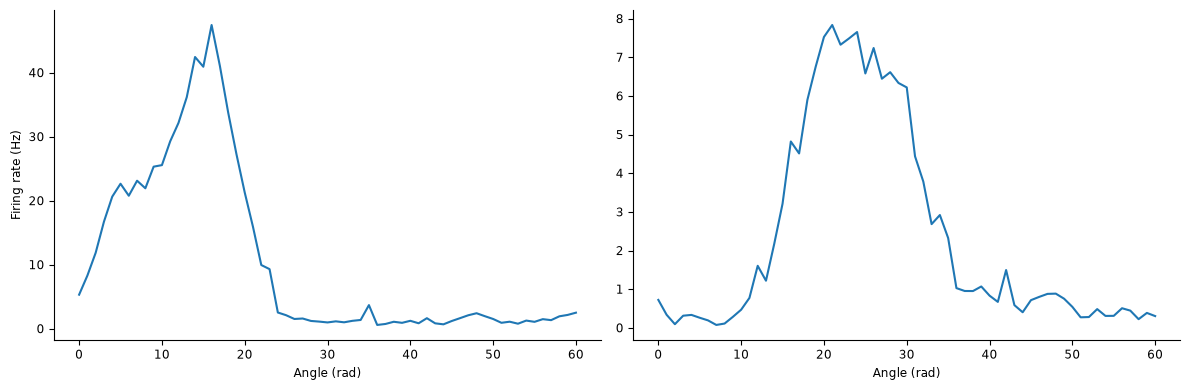

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tuning_curves[0])
ax[0].set_xlabel("Angle (rad)")
ax[0].set_ylabel("Firing rate (Hz)")
ax[1].plot(tuning_curves[1])
ax[1].set_xlabel("Angle (rad)")
plt.tight_layout()

Before using NeMoS, let's explore the data at the population level.

Let's plot the preferred heading

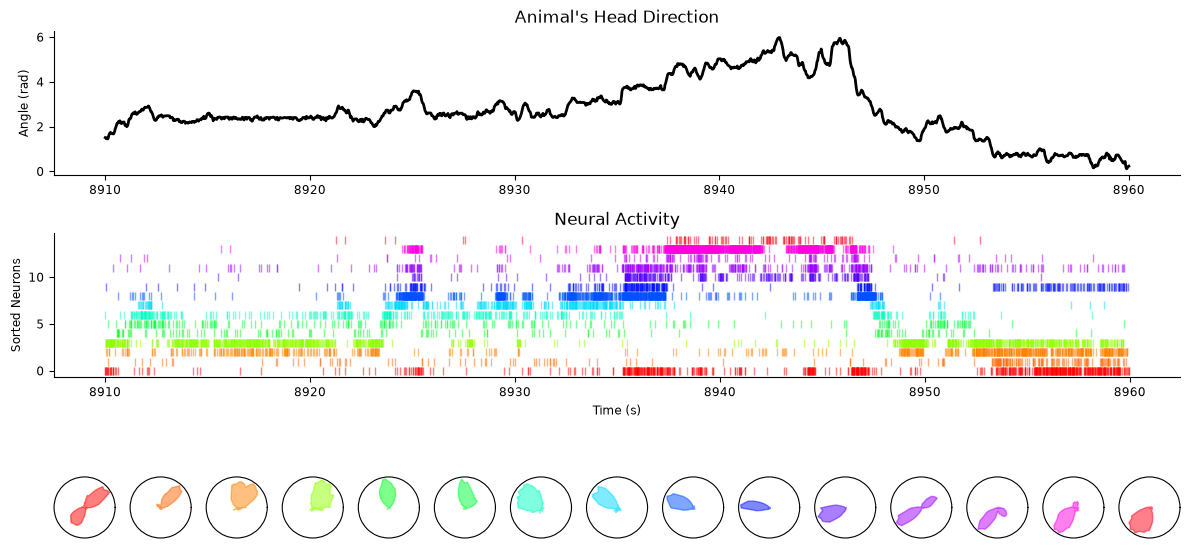

In [11]:
fig = doc_plots.plot_head_direction_tuning(
    tuning_curves, spikes, angle, threshold_hz=1, start=8910, end=8960
)

As we can see, the population activity tracks very well the current head-direction of the animal.
**Question : are neurons constantly tuned to head-direction and can we use it to predict the spiking activity of each neuron based only on the activity of other neurons?**

To fit the GLM faster, we will use only the first 3 min of wake

In [12]:
wake_ep = nap.IntervalSet(
    start=wake_ep.start[0], end=wake_ep.start[0] + 3 * 60
)

To use the GLM, we need first to bin the spike trains. Here we use pynapple

In [13]:
bin_size = 0.01
count = spikes.count(bin_size, ep=wake_ep)

Here we are going to rearrange neurons order based on their prefered directions.

In [14]:
pref_ang = tuning_curves.idxmax(dim="angles")

count = nap.TsdFrame(
    t=count.t,
    d=count.values[:, np.argsort(pref_ang)],
)

## NeMoS
It's time to use NeMoS. Our goal is to estimate the pairwise interaction between neurons.
This can be quantified with a GLM if we use the recent population spike history to predict the current time step.
### Self-Connected Single Neuron
To simplify our life, let's see first how we can model spike history effects in a single neuron.
The simplest approach is to use counts in fixed length window $i$, $y_{t-i}, \dots, y_{t-1}$ to predict the next
count $y_{t}$. Let's plot the count history,

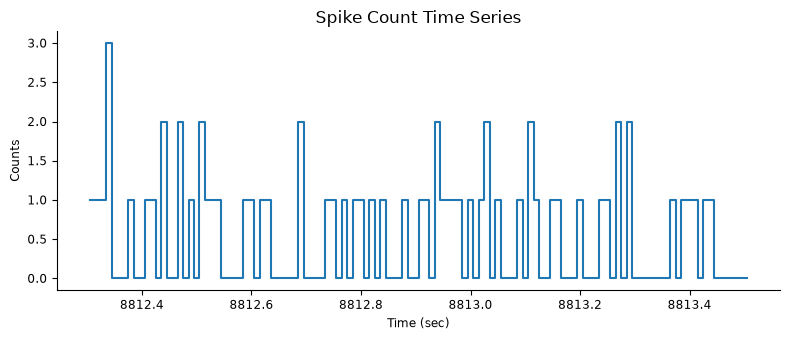

In [15]:
# select a neuron's spike count time series
neuron_count = count[:, 0]

# restrict to a smaller time interval
epoch_one_spk = nap.IntervalSet(
    start=count.time_support.start[0], end=count.time_support.start[0] + 1.2
)
plt.figure(figsize=(8, 3.5))
plt.step(
    neuron_count.restrict(epoch_one_spk).t, neuron_count.restrict(epoch_one_spk).d, where="post"
)
plt.title("Spike Count Time Series")
plt.xlabel("Time (sec)")
plt.ylabel("Counts")
plt.tight_layout()

#### Features Construction
Let's fix the spike history window size that we will use as predictor.

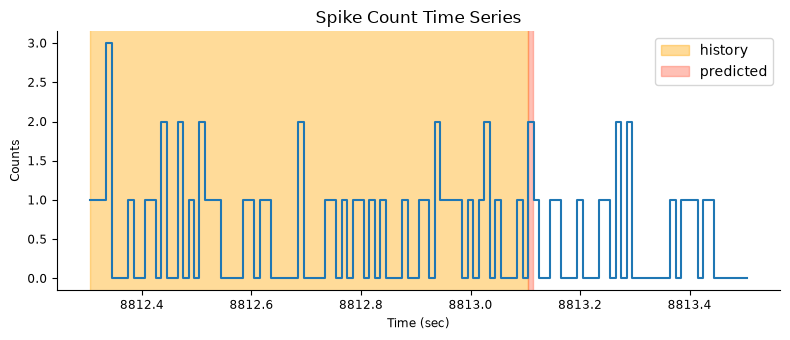

In [16]:
# set the size of the spike history window in seconds
window_size_sec = 0.8

doc_plots.plot_history_window(neuron_count, epoch_one_spk, window_size_sec);

For each time point, we shift our window one bin at the time and vertically stack the spike count history in a matrix.
Each row of the matrix will be used as the predictors for the rate in the next bin (red narrow rectangle in
the figure).

In [17]:
doc_plots.run_animation(neuron_count, epoch_one_spk.start[0])

If $t$ is smaller than the window size, we won't have a full window of spike history for estimating the rate.
One may think of padding the window (with zeros for example) but this may generate weird border artifacts.
To avoid that, we can simply restrict our analysis to times $t$ larger than the window and NaN-pad earlier
time-points;

A fast way to compute this feature matrix is convolving the counts with the identity matrix.
We can apply the convolution and NaN-padding in a single step using the
[`nemos.convolve.create_convolutional_predictor`](nemos.convolve.create_convolutional_predictor)
function.

In [18]:
# convert the prediction window to bins (by multiplying with the sampling rate)
window_size = int(window_size_sec * neuron_count.rate)

# convolve the counts with the identity matrix.
plt.close("all")
input_feature = nmo.convolve.create_convolutional_predictor(
    np.eye(window_size), neuron_count
)

# print the NaN indices along the time axis
print("NaN indices:\n", np.where(np.isnan(input_feature[:, 0]))[0])

NaN indices:
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]


The binned counts originally have shape "number of samples", we should check that the
dimension are matching our expectation

In [19]:
print(f"Time bins in counts: {neuron_count.shape[0]}")
print(f"Convolution window size in bins: {window_size}")
print(f"Feature shape: {input_feature.shape}")

Time bins in counts: 18000
Convolution window size in bins: 80
Feature shape: (18000, 80)


We can visualize the output for a few time bins

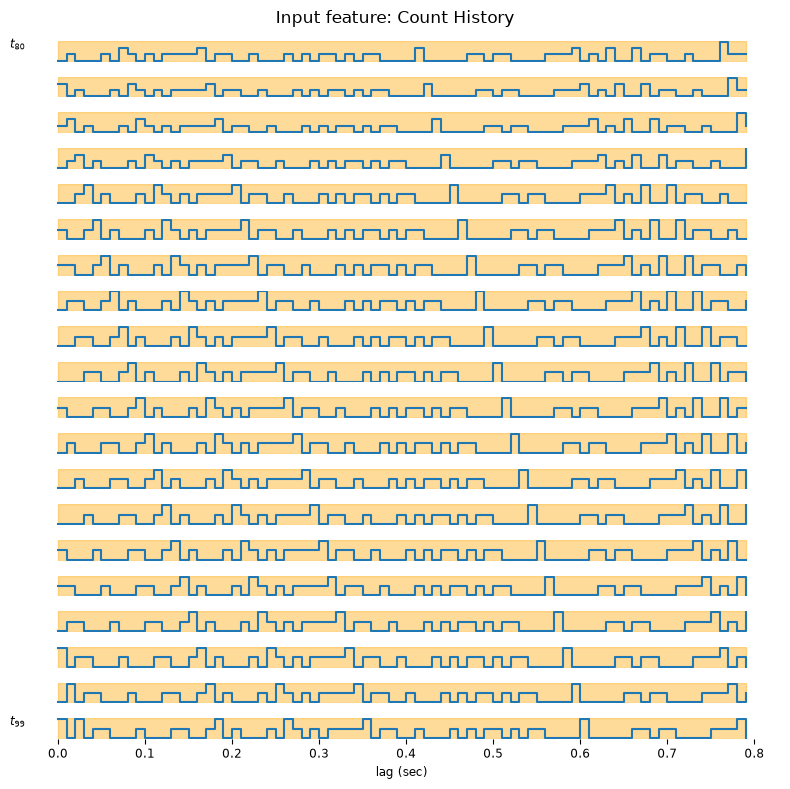

In [20]:
suptitle = "Input feature: Count History"
neuron_id = 0
doc_plots.plot_features(input_feature, count.rate, suptitle);

As you may see, the time axis is backward, this happens because convolution flips the time axis.
This is equivalent, as we can interpret the result as how much a spike will affect the future rate.
In the previous tutorial our feature was 1-dimensional (just the current), now
instead the feature dimension is 80, because our bin size was 0.01 sec and the window size is 0.8 sec.
We can learn these weights by maximum likelihood by fitting a GLM.




#### Fitting the Model

When working a real dataset, it is good practice to train your models on a chunk of the data and
use the other chunk to assess the model performance. This process is known as "cross-validation".
There is no unique strategy on how to cross-validate your model; What works best
depends on the characteristic of your data (time series or independent samples,
presence or absence of trials...), and that of your model. Here, for simplicity use the first
half of the wake epochs for training and the second half for testing. This is a reasonable
choice if the statistics of the neural activity does not change during the course of
the recording. We will learn about better cross-validation strategies with other
examples.

In [21]:
# construct the train and test epochs
duration = input_feature.time_support.tot_length("s")
start = input_feature.time_support["start"]
end = input_feature.time_support["end"]
first_half = nap.IntervalSet(start, start + duration / 2)
second_half = nap.IntervalSet(start + duration / 2, end)

Fit the glm to the first half of the recording and visualize the ML weights.

In [22]:
# define the GLM object
model = nmo.glm.GLM(solver_name="LBFGS")

# Fit over the training epochs
model.fit(
    input_feature.restrict(first_half),
    neuron_count.restrict(first_half)
)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f2c782a1120>
,regularizer,UnRegularized()
,fix_params,"(None, ...)"
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](80,)",Array([ 6.171...dtype=float64)


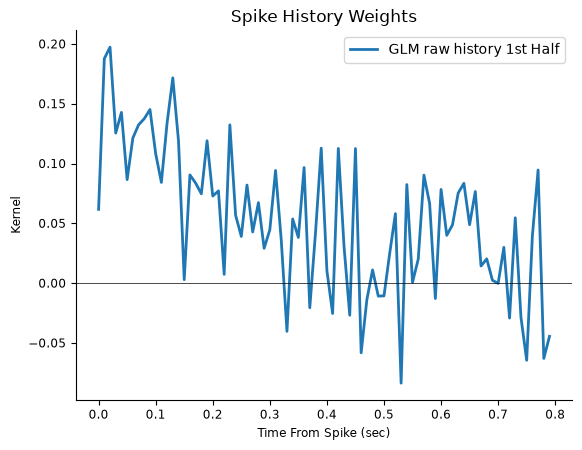

In [23]:
plt.figure()
plt.title("Spike History Weights")
plt.plot(np.arange(window_size) / count.rate, np.squeeze(model.coef_), lw=2, label="GLM raw history 1st Half")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time From Spike (sec)")
plt.ylabel("Kernel")
plt.legend()

The response in the previous figure seems noise added to a decay, therefore the response
can be described with fewer degrees of freedom. In other words, it looks like we
are using way too many weights to describe a simple response.
If we are correct, what would happen if we re-fit the weights on the other half of the data?
#### Inspecting the results

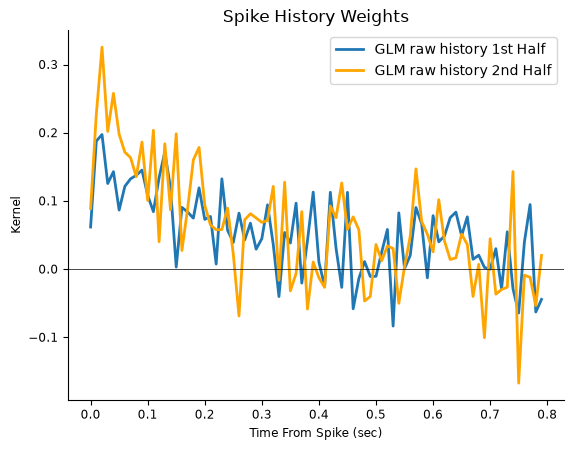

In [24]:
# fit on the test set

model_second_half = nmo.glm.GLM(solver_name="LBFGS")
model_second_half.fit(
    input_feature.restrict(second_half),
    neuron_count.restrict(second_half)
)

plt.figure()
plt.title("Spike History Weights")
plt.plot(np.arange(window_size) / count.rate, np.squeeze(model.coef_),
         label="GLM raw history 1st Half", lw=2)
plt.plot(np.arange(window_size) / count.rate,  np.squeeze(model_second_half.coef_),
         color="orange", label="GLM raw history 2nd Half", lw=2)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time From Spike (sec)")
plt.ylabel("Kernel")
plt.legend()

What can we conclude?

The fast fluctuations are inconsistent across fits, indicating that
they are probably capturing noise, a phenomenon known as over-fitting;
On the other hand, the decaying trend is fairly consistent, even if
our estimate is noisy. You can imagine how things could get
worst if we needed a finer temporal resolution, such 1ms time bins
(which would require 800 coefficients instead of 80).
What can we do to mitigate over-fitting now?

(head_direction_reducing_dimensionality)=
#### Reducing feature dimensionality
One way to proceed is to find a lower-dimensional representation of the response
by parametrizing the decay effect. For instance, we could try to model it
with an exponentially decaying function $f(t) = \exp( - \alpha t)$, with
$\alpha >0$ a positive scalar. This is not a bad idea, because we would greatly
simplify the dimensionality our features (from 80 to 1). Unfortunately,
there is no way to know a-priori what is a good parameterization. More
importantly, not all the parametrizations guarantee a unique and stable solution
to the maximum likelihood estimation of the coefficients (convexity).

In the GLM framework, the main way to construct a lower dimensional parametrization
while preserving convexity, is to use a set of basis functions.
For history-type inputs, whether of the spiking history or of the current
history, we'll use the raised cosine log-stretched basis first described in
[Pillow et al., 2005](https://www.jneurosci.org/content/25/47/11003). This
basis set has the nice property that their precision drops linearly with
distance from event, which is a makes sense for many history-related inputs
in neuroscience: whether an input happened 1 or 5 msec ago matters a lot,
whereas whether an input happened 51 or 55 msec ago is less important.

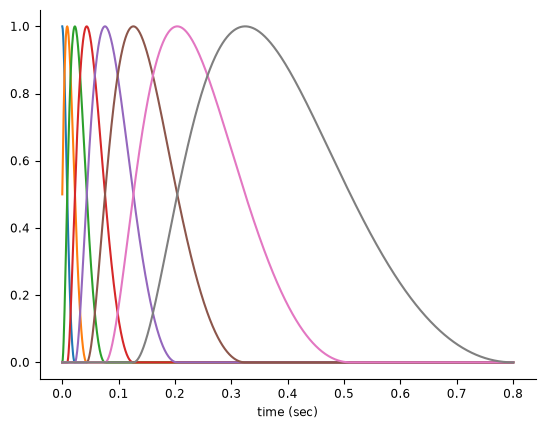

In [25]:
doc_plots.plot_basis();

:::{note}

We provide a handful of different choices for basis functions, and
selecting the proper basis function for your input is an important
analytical step. We will eventually provide guidance on this choice, but
for now we'll give you a decent choice.
:::

NeMoS includes [`Basis`](nemos_basis) objects to handle the construction and use of these
basis functions.

When we instantiate this object, the only arguments we need to specify is the
number of functions we want, the mode of operation of the basis (`"conv"`),
and the window size for the convolution. With more basis functions, we'll be able to
represent the effect of the corresponding input with the higher precision, at
the cost of adding additional parameters.

In [26]:
# a basis object can be instantiated in "conv" mode for convolving  the input.
basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=8, window_size=window_size, label="count_history"
)
print(basis)

# `basis.evaluate_on_grid` is a convenience method to view all basis functions
# across their whole domain:
time, basis_kernels = basis.evaluate_on_grid(window_size)

print(basis_kernels.shape)

# time takes equi-spaced values between 0 and 1, we could multiply by the
# duration of our window to scale it to seconds.
time *= window_size_sec

'count_history': RaisedCosineLogConv(n_basis_funcs=8, window_size=80, width=2.0, time_scaling=50.0, enforce_decay_to_zero=True)


(80, 8)


To appreciate why the raised-cosine basis can approximate well our response
we can learn a "good" set of weight for the basis element such that
a weighted sum of the basis approximates the GLM weights for the count history.
One way to do so is by minimizing the least-squares.

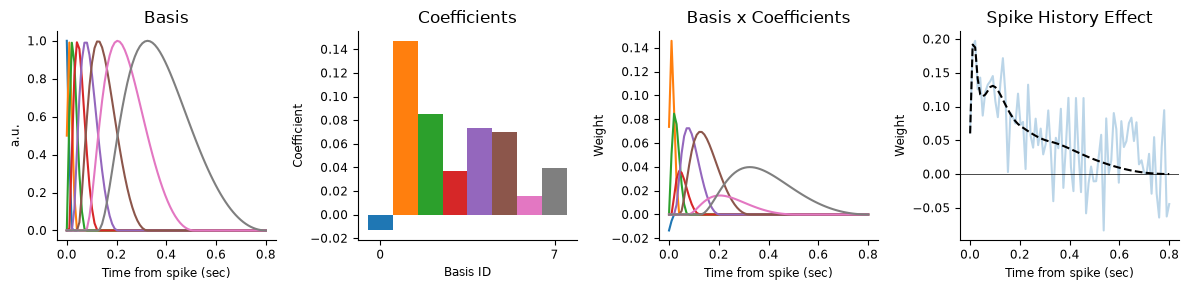

In [27]:
# compute the least-squares weights
lsq_coef, _, _, _ = np.linalg.lstsq(basis_kernels, np.squeeze(model.coef_), rcond=-1)

# plot the basis and the approximation
doc_plots.plot_weighted_sum_basis(time, model.coef_, basis_kernels, lsq_coef);

The first plot is the response of each of the 8 basis functions to a single
pulse. This is known as the impulse response function, and is a useful way to
characterize linear systems like our basis objects. The second plot are is a
bar plot representing the least-square coefficients. The third one are the
impulse responses scaled by the weights. The last plot shows the sum of the
scaled response overlapped to the original spike count history weights.

Our predictor previously was huge: every possible 80 time point chunk of the
data, for 1440000 total numbers. By using this basis set we can instead reduce
the predictor to 8 numbers for every 80 time point window for 144000 total
numbers. Basically an order of magnitude less. With 1ms bins we would have
achieved 2 order of magnitude reduction in input size. This is a huge benefit
in terms of memory allocation and, computing time. As an additional benefit,
we will reduce over-fitting.

Let's see our basis in action. We can "compress" spike history feature by convolving the basis
with the counts (without creating the large spike history feature matrix).
This can be performed in NeMoS by calling the "compute_features" method of basis.

Raw count history as feature: (18000, 80)
Compressed count history as feature: (18000, 8)


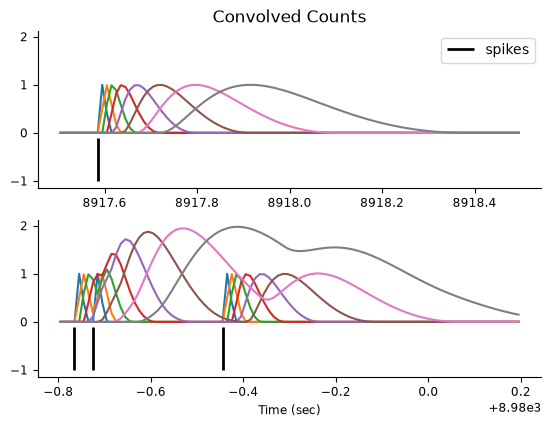

In [28]:
# equivalent to
# `nmo.convolve.create_convolutional_predictor(basis_kernels, neuron_count)`
conv_spk = basis.compute_features(neuron_count)

print(f"Raw count history as feature: {input_feature.shape}")
print(f"Compressed count history as feature: {conv_spk.shape}")

# Visualize the convolution results
epoch_one_spk = nap.IntervalSet(8917.5, 8918.5)
epoch_multi_spk = nap.IntervalSet(8979.2, 8980.2)

doc_plots.plot_convolved_counts(neuron_count, conv_spk, epoch_one_spk, epoch_multi_spk);

# find interval with two spikes to show the accumulation, in a second row

Now that we have our "compressed" history feature matrix, we can fit the ML parameters for a GLM.




#### Fit and compare the models

In [29]:
# use restrict on interval set training
model_basis = nmo.glm.GLM(solver_name="LBFGS")
model_basis.fit(conv_spk.restrict(first_half), neuron_count.restrict(first_half))

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f2c782a1120>
,regularizer,UnRegularized()
,fix_params,"(None, ...)"
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](8,)",Array([-0.025...dtype=float64)


We can plot the resulting response, noting that the weights we just learned needs to be "expanded" back
to the original `window_size` dimension by multiplying them with the basis kernels.
We have now 8 coefficients,

In [30]:
print(model_basis.coef_)

[-0.02592858  0.16032948  0.07191898  0.07063985  0.03755858  0.10458721
 -0.01092549  0.05780688]


In order to get the response we need to multiply the coefficients by their corresponding
basis function, and sum them.

In [31]:
self_connection = np.matmul(basis_kernels, np.squeeze(model_basis.coef_))

print(self_connection.shape)

(80,)


We can now compare this model that based on the raw count history.

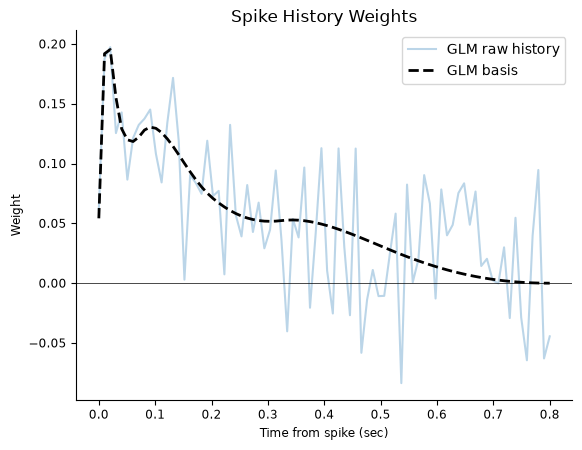

In [32]:
plt.figure()
plt.title("Spike History Weights")
plt.plot(time, np.squeeze(model.coef_), alpha=0.3, label="GLM raw history")
plt.plot(time, self_connection, "--k", label="GLM basis", lw=2)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time from spike (sec)")
plt.ylabel("Weight")
plt.legend()

Let's check if our new estimate does a better job in terms of over-fitting. We can do that
by visual comparison, as we did previously. Let's fit the second half of the dataset.

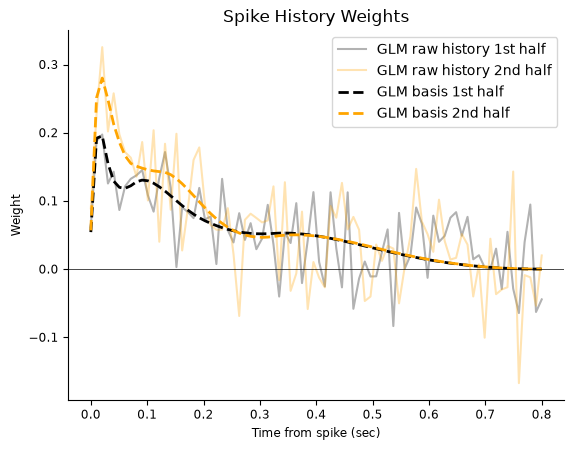

In [33]:
model_basis_second_half = nmo.glm.GLM(solver_name="LBFGS")
model_basis_second_half.fit(conv_spk.restrict(second_half), neuron_count.restrict(second_half))

# compute responses for the 2nd half fit
self_connection_second_half = np.matmul(basis_kernels, np.squeeze(model_basis_second_half.coef_))

plt.figure()
plt.title("Spike History Weights")
plt.plot(time, np.squeeze(model.coef_), "k", alpha=0.3, label="GLM raw history 1st half")
plt.plot(time, np.squeeze(model_second_half.coef_), alpha=0.3, color="orange", label="GLM raw history 2nd half")
plt.plot(time, self_connection, "--k", lw=2, label="GLM basis 1st half")
plt.plot(time, self_connection_second_half, color="orange", lw=2, ls="--", label="GLM basis 2nd half")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Time from spike (sec)")
plt.ylabel("Weight")
plt.legend()

Or we can score the model predictions using both one half of the set for training
and the other half for testing.

In [34]:
# compare model scores, as expected the training score is better with more parameters
# this may could be over-fitting.
print(f"full history train score: {model.score(input_feature.restrict(first_half), neuron_count.restrict(first_half), score_type='pseudo-r2-Cohen')}")
print(f"basis train score: {model_basis.score(conv_spk.restrict(first_half), neuron_count.restrict(first_half), score_type='pseudo-r2-Cohen')}")

full history train score: 0.17631957889926986
basis train score: 0.16441869900240072


To check that, let's try to see ho the model perform on unseen data and obtaining a test
score.

In [35]:
print(f"\nfull history test score: {model.score(input_feature.restrict(second_half), neuron_count.restrict(second_half), score_type='pseudo-r2-Cohen')}")
print(f"basis test score: {model_basis.score(conv_spk.restrict(second_half), neuron_count.restrict(second_half), score_type='pseudo-r2-Cohen')}")


full history test score: 0.23146649539934783
basis test score: 0.23757637672266793


Let's extract and plot the rates

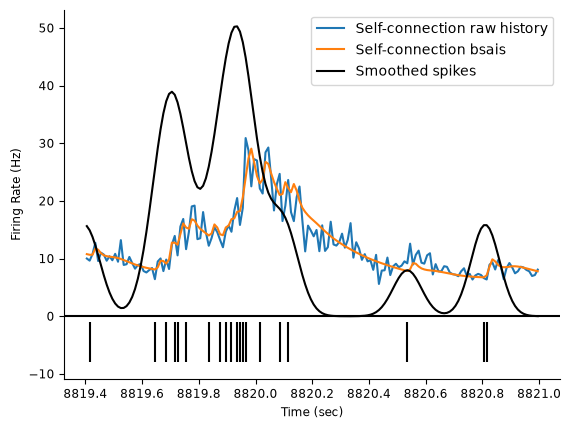

In [36]:
rate_basis = model_basis.predict(conv_spk) * conv_spk.rate
rate_history = model.predict(input_feature) * conv_spk.rate
ep = nap.IntervalSet(start=8819.4, end=8821)

# plot the rates
doc_plots.plot_rates_and_smoothed_counts(
    neuron_count,
    {"Self-connection raw history":rate_history, "Self-connection bsais": rate_basis}
);

### All-to-all Connectivity
The same approach can be applied to the whole population. Now the firing rate of a neuron
is predicted not only by its own count history, but also by the rest of the
simultaneously recorded population. We can convolve the basis with the counts of each neuron
to get an array of predictors of shape, `(num_time_points, num_neurons * num_basis_funcs)`.

#### Preparing the features

In [37]:
# re-initialize basis
basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=8, window_size=window_size, label="population_history"
)

# convolve all the neurons
convolved_count = basis.compute_features(count)

Check the dimension to make sure it make sense
Shape should be (n_samples, n_basis_func * n_neurons)

In [38]:
print(f"Convolved count shape: {convolved_count.shape}")

Convolved count shape: (18000, 152)


#### Fitting the Model
This is an all-to-all neurons model.
We are using the class [`PopulationGLM`](nemos.glm.PopulationGLM) to fit the whole population at once.

:::{note}

Once we condition on past activity, log-likelihood of the population is the sum of the log-likelihood
of individual neurons. Maximizing the sum (i.e. the population log-likelihood) is equivalent to
maximizing each individual term separately (i.e. fitting one neuron at the time).
:::

In [39]:
model = nmo.glm.PopulationGLM(
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.1
    ).fit(convolved_count, count)

#### Comparing model predictions.
Predict the rate (counts are already sorted by tuning prefs)

In [40]:
predicted_firing_rate = model.predict(convolved_count) * conv_spk.rate

Plot fit predictions over a short window not used for training.

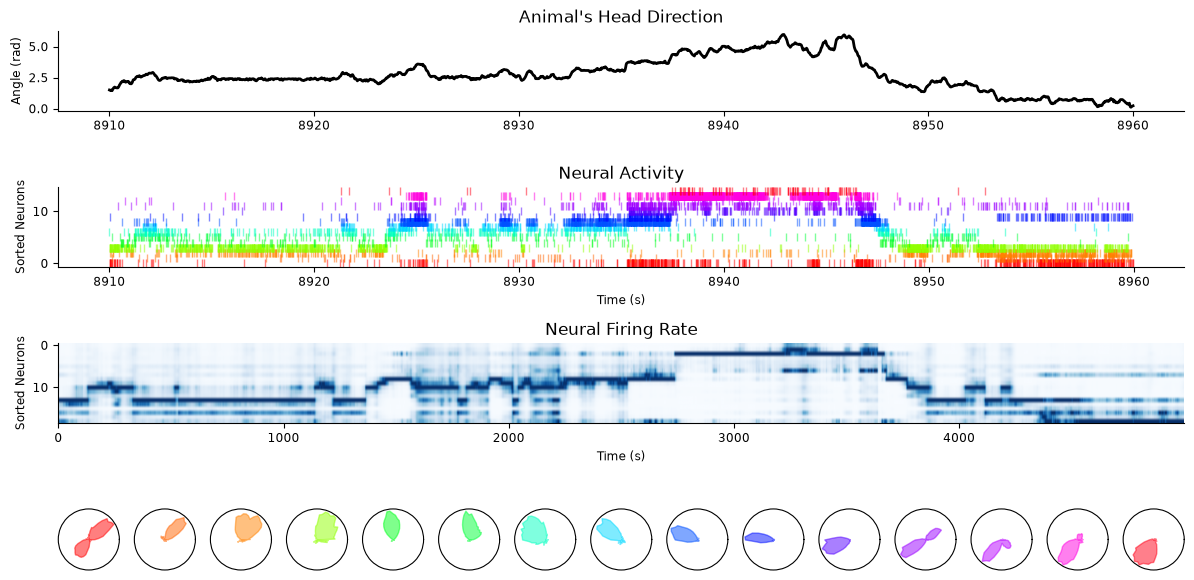

In [41]:
# use pynapple for time axis for all variables plotted for tick labels in imshow
doc_plots.plot_head_direction_tuning_model(tuning_curves, predicted_firing_rate, spikes, angle, threshold_hz=1,
                                          start=8910, end=8960, cmap_label="hsv");

Let's see if our firing rate predictions improved and in what sense.

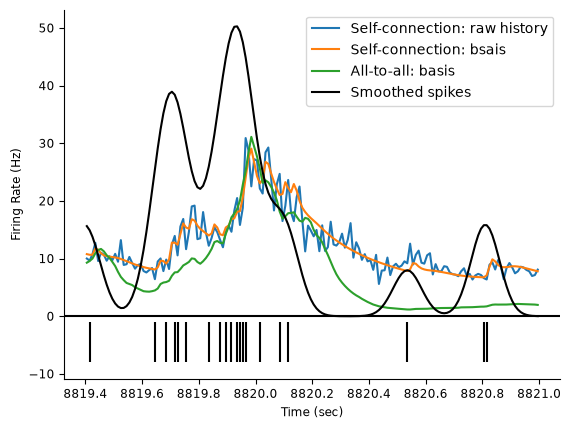

In [42]:
# mkdocs_gallery_thumbnail_number = 2
fig = doc_plots.plot_rates_and_smoothed_counts(
    neuron_count,
    {"Self-connection: raw history": rate_history,
     "Self-connection: bsais": rate_basis,
     "All-to-all: basis": predicted_firing_rate[:, 0]}
)

#### Visualizing the connectivity
Compute the tuning curve form the predicted rates.

In [43]:
tuning = nap.compute_tuning_curves(
    predicted_firing_rate,
    features=angle,
    bins=61,
    range=(0, 2 * np.pi),
    feature_names=["angles"]
)

Extract the weights and store it in a `(n_neurons, n_neurons, n_basis_funcs)` array.

In [44]:
# use split_by_feature to reshape the coefficients
weights_dict = basis.split_by_feature(model.coef_, axis=0)

# get the component weights indexing with the basis label.
weights = weights_dict["population_history"]
print(weights.shape)

(19, 8, 19)


Multiply the weights by the basis, to get the history filters.

In [45]:
responses = np.einsum("jki,tk->ijt", weights, basis_kernels)

print(responses.shape)

(19, 19, 80)


Finally, we can visualize the pairwise interactions by plotting
all the coupling filters.

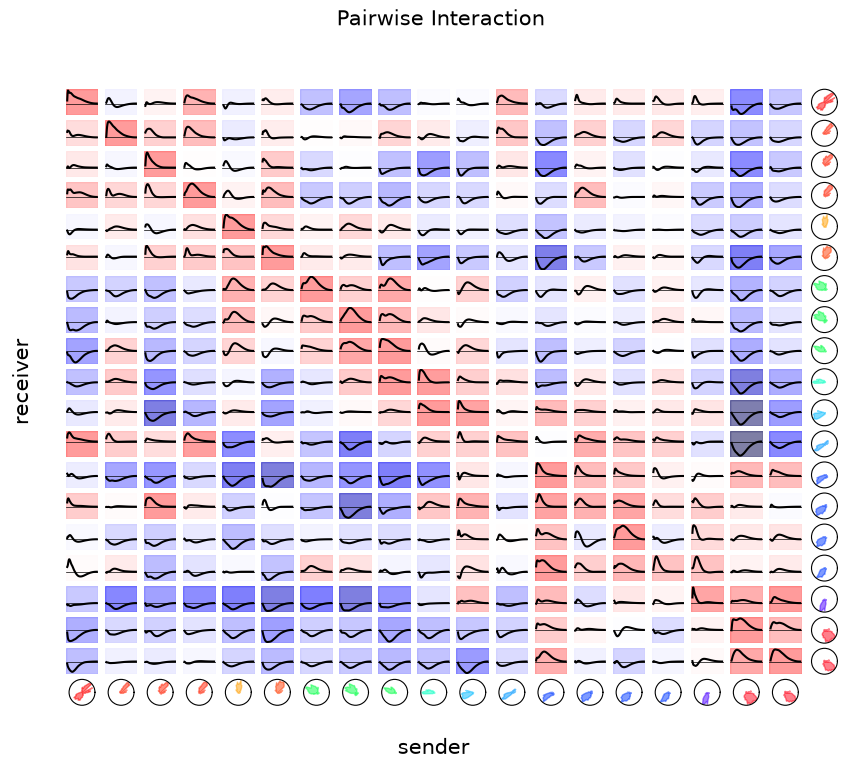

In [46]:
fig = doc_plots.plot_coupling(responses, tuning)

In [47]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/tutorials"
# if local store in assets
else:
   path = Path("../_build/html/_static/thumbnails/tutorials")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_02_head_direction.svg")